In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import grad, vmap, random
import optax
import diffrax
from seaborn import kdeplot
import wandb
from ot.lp import wasserstein_1d
import argparse
import pickle

from triangular_transport.flows.flow_trainer import (
    NNTrainer
)
from triangular_transport.flows.sde_flow_trainer import NNSDE

from triangular_transport.flows.interpolants import (
    linear_interpolant,
    linear_interpolant_der,
    trig_interpolant,
    trig_interpolant_der,
    sigmoid_interpolant,
    sigmoid_interpolant_der,
    linear_interpolant_noise,
    linear_interpolant_der_noise,
)
from triangular_transport.flows.loss_functions import vec_field_loss, denoiser_loss
from triangular_transport.networks.flow_networks import MLP
from triangular_transport.flows.methods.sampling import inf_train_gen
from triangular_transport.flows.dataloaders import (
    standard_gaussian_reference_sampler,
    gaussian_reference_sampler
)
plt.style.use("ggplot")

/home/verano13/miniconda3/envs/stochastic-interpolants/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
ys = np.random.uniform(low=-3.0, high=3.0, size=(100000, 1))
# ys = 2.0 * np.ones((1000000, 1))
us = np.tanh(ys) + np.random.gamma(shape=1.0, scale=0.3, size=(100000, 1))
# us = np.tanh(ys) + 0.1 * np.random.randn(100000, 1)
data = np.hstack([ys, us])

<Axes: ylabel='Density'>

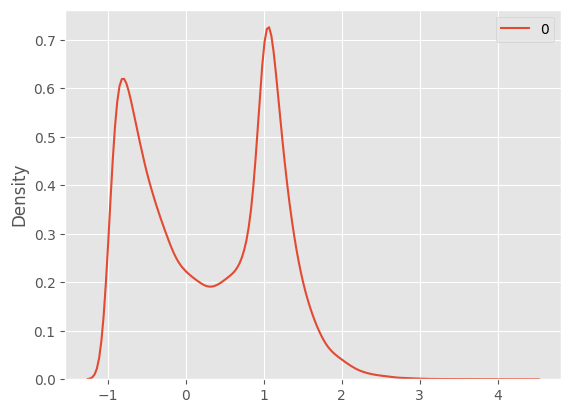

In [6]:
kdeplot(us)

Text(0, 0.5, '$u$')

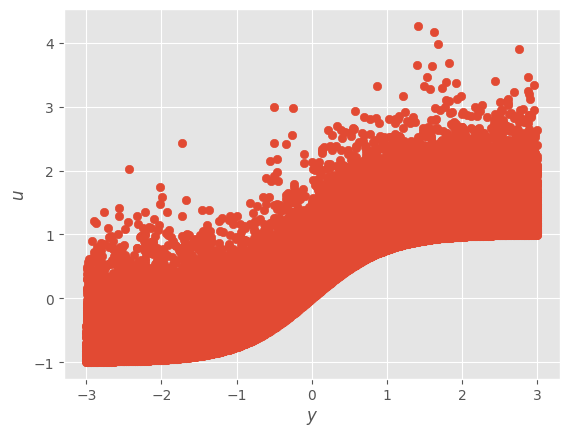

In [7]:
plt.scatter(ys, us)
plt.xlabel(r"$y$")
plt.ylabel(r"$u$")

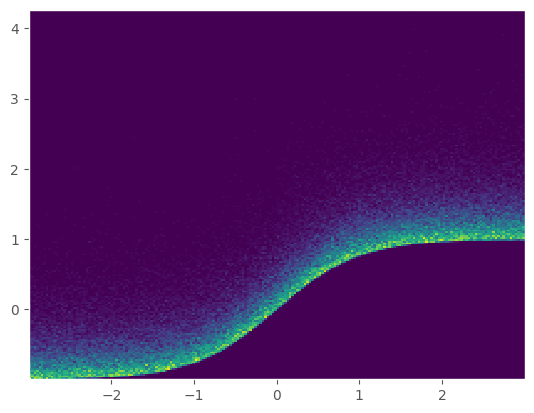

In [8]:
plt.hist2d(ys.squeeze(), us.squeeze(), bins=200);

In [9]:
def exp_reference_sampler(
    key: random.PRNGKey, shape: tuple[int, int]
):
    samples = 0.3 * (random.exponential(key=key, shape=shape))
    return samples

@vmap
def sigmoid_interpolant(t: jnp.array, x1: jnp.array, x0: jnp.array, z):
    return (1 - sigmoid(t)) * x0 + sigmoid(t) * x1 + gamma_vmap(t) * z

def sigmoid(t: float) -> float:
    return jax.nn.sigmoid(27 * (t - 0.35)) # Changed this to 25
sigmoid_dot = vmap(grad(sigmoid))

@vmap
def sigmoid_interpolant_der(t: jnp.array, x1: jnp.array, x0: jnp.array, z):
    return sigmoid_dot(t) * (x1 - x0) + gammadot(t) * z

@vmap
def hsu_interpolant(t: jnp.array, x1: jnp.array, x0: jnp.array):
    s = (t - 1) * (t - 1)
    return s * x0 + (1 - s) * x1

@vmap
def hsu_interpolant_der(t, x1, x0):
    return (2 * t - 2) * x0 + (-2 * t + 2) * x1

def gamma_fn(t):
    return 0.1 * jnp.sqrt(2 * (t - t**2) + 1e-8)

@vmap
def gammadot(t):
    return 0.1 * (1 - 2 * t) / jnp.sqrt(t - t ** 2 + 1e-8)

gamma_vmap = vmap(gamma_fn)


In [12]:
samps2 = np.load("samps_2.npy")

In [13]:
key1 = random.key(2)
key1, key2 = random.split(key1, 2)
epochs = 400
x1_data = data.copy()
train_dim = 4096 * 16
batch_size = 2048
# batch_size = 1024
# batch_size = hyperparams["batch_size"]
batch_size = min(batch_size, train_dim)
batch_size -= 1
steps_per_epoch = int(np.ceil(train_dim / batch_size))
steps = steps_per_epoch * epochs
print_every = 10000
yu_dimension = (1, 1)
dim = yu_dimension[0] + yu_dimension[1]
# hidden_layer_list = [256] * 4 if train_dim < 8000 else [1024] * 8
hidden_layer_list2 = [350] * 5
hidden_layer_list1 = [256] * 4
# hidden_layer_list = [1024] * 8
target_data = x1_data[:train_dim, :]
velocity = MLP(
    key=key1,
    dim=dim,
    time_varying=True,
    w=hidden_layer_list1,
    num_layers=len(hidden_layer_list1) + 1,
    activation_fn=jax.nn.gelu,  # GeLU worked well
)
v_schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=1e-3,
    warmup_steps=400,
    decay_steps=steps,
    end_value=1e-5,
)

v_optimizer = optax.chain(
    optax.clip_by_global_norm(1.0), optax.rmsprop(v_schedule)
)
interpolant = linear_interpolant
interpolant_der = linear_interpolant_der
interpolant_args = {"t": None, "x1": None, "x0": None}

trainer = NNTrainer(
    target_density=None,
    model=velocity,
    optimizer=v_optimizer,
    interpolant=interpolant,
    interpolant_der=interpolant_der,
    reference_sampler=standard_gaussian_reference_sampler,
    loss=vec_field_loss,
    interpolant_args=interpolant_args,
    yu_dimension=yu_dimension,
    t_sampler=random.beta,
    # reference_sampler_args=reference_sampler_args,
)

trainer.train(
    train_data=target_data,
    train_dim=train_dim,
    batch_size=batch_size,
    steps=steps,
    x0_data=None,
    print_every=print_every,
);

Training neural network


  1%|          | 144/13200 [00:03<03:03, 71.20it/s] 

step = 0, train_loss = 0.03209715336561203


 77%|███████▋  | 10126/13200 [00:17<00:04, 710.53it/s]

step = 10000, train_loss = -1.3004781007766724


100%|██████████| 13200/13200 [00:21<00:00, 610.42it/s]

step = 13199, train_loss = -1.18876314163208


In [24]:
trainer.vmap_model(jnp.array([[1.0, 2., 0.]]))

Array([[ 0.04923093, 12.376623  ]], dtype=float32)

In [14]:
cond_vals = 2
nsamples = 100000
solver_args = {"solver": diffrax.Dopri5(), "max_steps": 50000, "stepsize_controller": diffrax.PIDController(rtol=1e-4, atol=1e-6)}
# solver_args = {"saveat": "t1", "eps": 0.5, "stepsize_controller": diffrax.PIDController(rtol=1e-4, atol=1e-6)}
cond_samples = trainer.conditional_sample(
    cond_values=cond_vals,
    nsamples=nsamples,
    u0_cond=None,
    solver_args=solver_args,
)

In [21]:
ys_test = cond_vals * np.ones((100000, 1))
samps2 = np.tanh(ys_test) + 0.1 * np.random.randn(100000, 1)

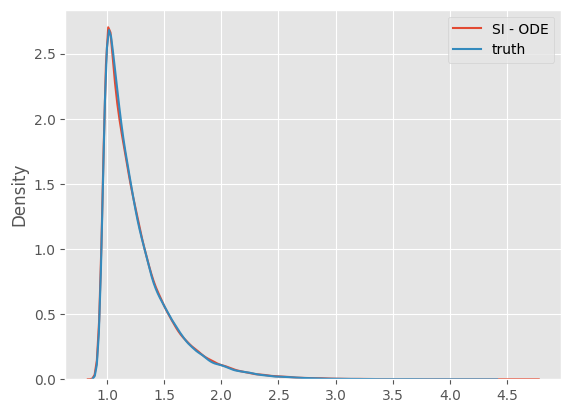

In [15]:
kdeplot(cond_samples[:, 1], label="SI - ODE")
# kdeplot(mcmc_samps2[0].squeeze(), label="MCMC")
kdeplot(samps2.squeeze(), label="truth")
plt.legend()
# plt.yscale('log')

In [16]:
np.mean(cond_samples[:, 1] < np.tanh(2))

Array(0.01191, dtype=float32)

In [17]:
wasserstein_1d(np.asarray(cond_samples[:, 1]), samps2.squeeze(), p=2)

np.float64(0.0012666579551865239)

In [15]:
np.tanh(2)

np.float64(0.9640275800758169)

In [ ]:
ys = -3.0 * np.ones((100000, 1))
us = np.tanh(ys) + np.random.gamma(shape=1.0, scale=0.3, size=(100000, 1))
data = np.hstack([ys, us])
np.save("samps_3.npy", us)

: 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from seaborn import kdeplot
plt.style.use("ggplot")

In [8]:
si_array = np.zeros((10, 23))
for i in range(10):
    si_array[i, :] = np.load(f"converge_results_3/run_{i:02d}/nn_conv_wd_{i}.npy")
wd_ode = np.mean(si_array, axis=0)

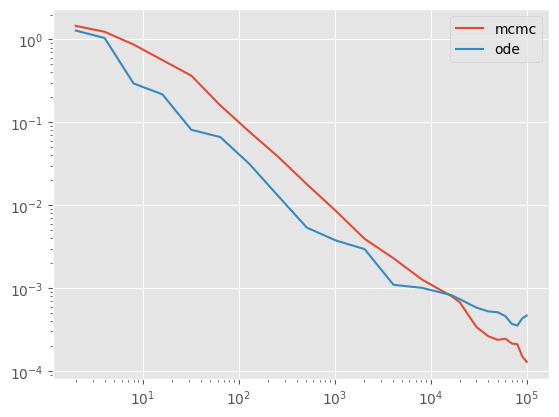

In [9]:
wd_mcmc = np.load("mcmc_results_3/avg_wd_mcmc.npy")
sample_nos = np.load("sample_no_list.npy")
plt.plot(sample_nos, wd_mcmc, label="mcmc")
plt.plot(sample_nos, wd_ode, label="ode")
plt.xscale("log")
plt.yscale("log")
plt.legend()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

mcmc_0 = np.load("mcmc_results_0/avg_wd_mcmc.npy")
mcmc_2 = np.load("mcmc_results_2/avg_wd_mcmc.npy")
mcmc_3 = np.load("mcmc_results_3/avg_wd_mcmc.npy")

si_array = np.zeros((10, 23))
for i in range(10):
    si_array[i, :] = np.load(f"converge_results_0/run_{i:02d}/nn_conv_wd_{i}.npy")
ode_mean0 = np.mean(si_array, axis=0)

si_array = np.zeros((10, 23))
for i in range(10):
    si_array[i, :] = np.load(f"converge_results_2/run_{i:02d}/nn_conv_wd_{i}.npy")
ode_mean2 = np.mean(si_array, axis=0)

si_array = np.zeros((10, 23))
for i in range(10):
    si_array[i, :] = np.load(f"converge_results_3/run_{i:02d}/nn_conv_wd_{i}.npy")
ode_mean3 = np.mean(si_array, axis=0)

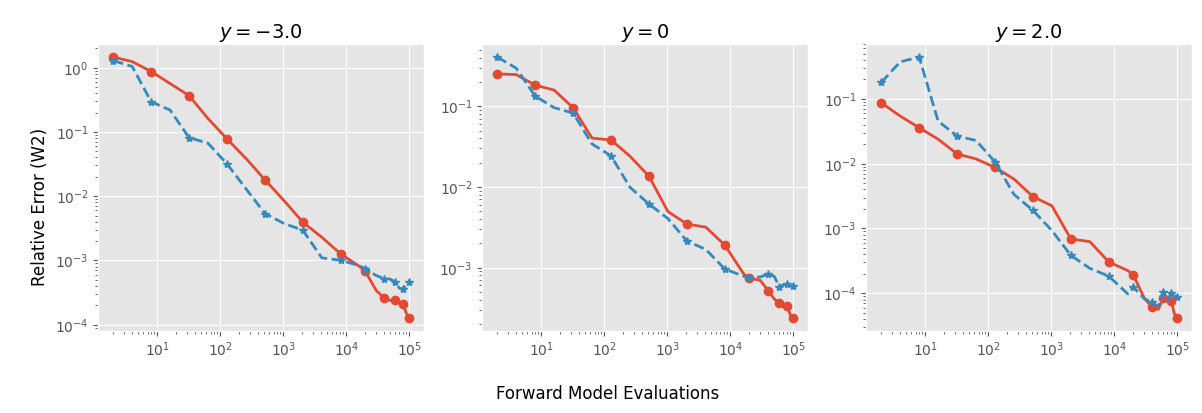

In [2]:
eps = 1e-300
sample_no_list = np.load("sample_no_list.npy")
fig, ax = plt.subplots(1, 3, figsize=(12,4))

ax[1].plot(sample_no_list, mcmc_0, marker="o", label="MCMC", markevery=2, linewidth=2, markersize=6,)
imode0, = ax[1].plot(sample_no_list, ode_mean0, marker="*", linestyle="dashed", label="SI (ODE)", linewidth=2, markersize=6, markevery=2)
# ax[0].fill_between(sample_no_list, np.clip(l_ode_0, eps, None), np.clip(h_ode_0, eps, None), alpha=0.12, color=imode0.get_color())
# imsde0, = ax[0].plot(sample_no_list, sde_mean0, marker="^", linestyle="dashdot", label="SI (SDE)", markevery=2, linewidth=2, markersize=6,)
# ax[0].fill_between(sample_no_list, np.clip(l_sde_0, eps, None), np.clip(h_sde_0, eps, None), alpha=0.12, color=imsde0.get_color())
# imker0, = ax[0].plot(sample_no_list, ker_mean0, marker="P", linestyle="dotted", label="SI (Ker)", markevery=2, linewidth=2, markersize=6,)
# ax[0].fill_between(sample_no_list, np.clip(l_ker_0, eps, None), np.clip(h_ker_0, eps, None), alpha=0.12, color=imker0.get_color())
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_title(r"$y = 0$", fontsize=14, pad=4)

ax[2].plot(sample_no_list, mcmc_2, marker="o", markevery=2, linewidth=2, markersize=6,)
imode1, = ax[2].plot(sample_no_list, ode_mean2, marker="*", linestyle="dashed", linewidth=2, markersize=6, markevery=2)
# ax[1].fill_between(sample_no_list, np.clip(l_ode_1, eps + 0.002, None), np.clip(h_ode_1, eps, None), alpha=0.12, color=imode1.get_color())
# imsde1, = ax[1].plot(sample_no_list, sde_mean2, marker="^", linestyle="dashdot", markevery=2, linewidth=2, markersize=6,)f
# ax[1].fill_between(sample_no_list, np.clip(l_sde_1, eps, None), np.clip(h_sde_1, eps, None), alpha=0.12, color=imsde1.get_color())
# imker1, = ax[1].plot(sample_no_list, ker_mean_0, marker="P", linestyle="dotted", label="SI (Ker) - WD", markevery=2, linewidth=2, markersize=6,)
# ax[1].fill_between(sample_no_list, np.clip(l_ker_1, eps, None), np.clip(h_ker_1, eps, None), alpha=0.12, color=imker1.get_color())
ax[2].set_xscale("log")
ax[2].set_yscale("log")
ax[2].set_title(r"$y = 2.0$", fontsize=14, pad=4)

ax[0].plot(sample_no_list, mcmc_3, marker="o", markevery=2, linewidth=2, markersize=6,)
imode2, = ax[0].plot(sample_no_list, ode_mean3, marker="*", linestyle="dashed", linewidth=2, markersize=6, markevery=2)
# ax[2].fill_between(sample_no_list, np.clip(l_ode_4, eps, None), np.clip(h_ode_4, eps, None), alpha=0.12, color=imode2.get_color())
# imsde2, = ax[2].plot(sample_no_list, sde_mean3, marker="^", linestyle="dashdot", markevery=2, linewidth=2, markersize=6,)
# ax[2].fill_between(sample_no_list, np.clip(l_sde_4, eps, None), np.clip(h_sde_4, eps, None), alpha=0.12, color=imsde2.get_color())
# imker2, = ax[2].plot(sample_no_list, ker_mean_4, marker="P", linestyle="dotted", markevery=2, linewidth=2, markersize=6,)
# ax[2].fill_between(sample_no_list, np.clip(l_ker_4, eps, None), np.clip(h_ker_4, eps, None), alpha=0.12, color=imker2.get_color())
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_title(r"$y = -3.0$", fontsize=14, pad=4)

fig.supylabel("Relative Error (W2)")
fig.supxlabel("Forward Model Evaluations")
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper left",
    ncol=2,
    frameon=False,
    fontsize=10,          # or smaller if needed
    handlelength=1.4,     # length of line samples
    handletextpad=0.4,    # space between handle and text
    columnspacing=0.8,    # space between columns
    labelspacing=0.3,     # vertical space between rows
    borderaxespad=0.2,    # distance to axes
)

plt.tight_layout()
plt.savefig("images/conv_plot_tanh.pdf")

<Axes: ylabel='Density'>

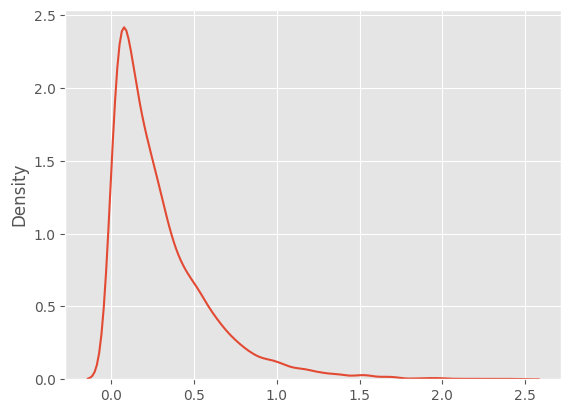

In [14]:
kdeplot(np.random.gamma(1.0, 0.3, (10000,)))

In [28]:
wd_ode

array([0.63451568, 0.41766168, 0.10966529, 0.07694057, 0.04771163,
       0.00999521, 0.01177163, 0.00552471, 0.00469672, 0.00350714,
       0.00332481, 0.00338855, 0.00300786, 0.00336981, 0.00318815,
       0.00280332, 0.00276397, 0.00255415, 0.00268562, 0.00264415,
       0.00259734, 0.00286537, 0.00287775])

In [16]:
wd_ode

array([0.13412312, 0.09721486, 0.05257391, 0.02174661, 0.01637451,
       0.00952784, 0.00704219, 0.00512395, 0.00220158, 0.0012635 ,
       0.00090717, 0.00050867, 0.00081339, 0.00079162, 0.00064851,
       0.00064886, 0.000568  , 0.00057402, 0.00053329, 0.00056679,
       0.00066016, 0.00055071, 0.00060032])

In [29]:
wd_mcmc

array([1.45973613e+00, 1.23887546e+00, 8.69315065e-01, 5.63948389e-01,
       3.66109573e-01, 1.60777931e-01, 7.76258876e-02, 3.86254426e-02,
       1.79378467e-02, 8.56143449e-03, 3.93476838e-03, 2.29255898e-03,
       1.25895799e-03, 8.02850409e-04, 6.78867536e-04, 3.38814062e-04,
       2.61956109e-04, 2.37569547e-04, 2.45639281e-04, 2.14583241e-04,
       2.10175756e-04, 1.49674307e-04, 1.28872810e-04])

In [273]:
(wd_ode * base_wd)[-1]

np.float64(0.0013145568431204887)

In [8]:
mcmc_samps2 = np.load("mcmc_results_2/mcmc_samps.npy")
samps2 = np.load("samps_2.npy")

In [18]:
np.mean(mcmc_samps2[9].squeeze() < np.tanh(2))

np.float64(2e-05)

In [8]:
samps2.shape

(100000, 1)

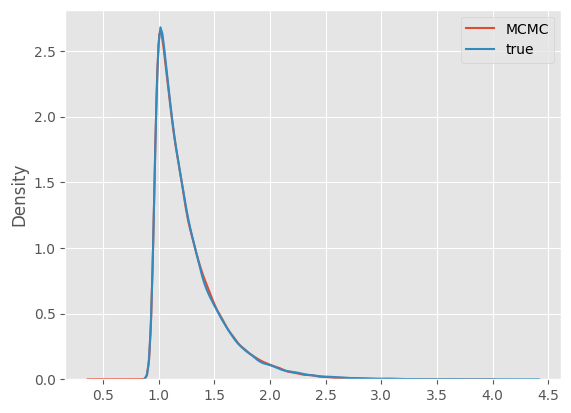

In [18]:
kdeplot(np.vstack(mcmc_samps2[9]).squeeze(), label="MCMC")
kdeplot(samps2.squeeze(), label="true")
plt.legend()

In [24]:
mcmc_samps2[2]

array([[1.23302841],
       [1.23302841],
       [1.19346809],
       ...,
       [1.20813835],
       [1.20813835],
       [1.20813835]], shape=(100000, 1))

In [61]:
from ot.lp import wasserstein_1d as wd
from tqdm.auto import tqdm
no_trials = 10
sample_no_list = sample_nos
mcmc_samps = mcmc_samps2.copy()
wd_array = np.zeros((no_trials, len(sample_no_list)))
for j in tqdm(range(no_trials)):
    for i, sample_no in enumerate(sample_no_list):
        subsamps = mcmc_samps[j, :, :]
        subsamps = subsamps[:sample_no, :]
        wd1 = wd(
            subsamps.reshape(-1),
            samps2.reshape(-1),
            p=2
        )
        wd_array[j, i] = wd1

100%|██████████| 10/10 [00:02<00:00,  3.70it/s]


In [62]:
wd_array

array([[1.80818821e-01, 8.64372774e-02, 3.47308019e-02, 2.83418508e-02,
        3.22102530e-02, 3.45670732e-02, 1.83900528e-02, 3.24207475e-03,
        2.79667422e-03, 2.79707319e-03, 4.61417948e-04, 3.83252350e-04,
        4.83289047e-04, 5.33750607e-04, 2.17664506e-04, 1.36298135e-04,
        4.35123303e-05, 3.90029246e-05, 3.21980995e-05, 8.81350369e-05,
        1.25807776e-04, 7.74574301e-05, 6.22126386e-05],
       [1.76186702e-01, 1.41068398e-01, 1.19177962e-01, 5.72408726e-02,
        1.72381066e-02, 8.12607696e-03, 7.63507955e-03, 1.07528101e-02,
        3.10577072e-03, 1.43208655e-03, 7.79176519e-04, 1.04122810e-03,
        4.10852188e-04, 1.99884574e-04, 1.44716788e-04, 1.12911107e-04,
        2.60440434e-04, 4.85482694e-05, 4.33357163e-05, 3.15585000e-05,
        1.90997449e-05, 2.16637948e-05, 2.13279725e-05],
       [9.10182606e-02, 8.39413577e-02, 8.45898615e-02, 3.11164444e-02,
        1.12627281e-02, 6.37746813e-02, 1.90522301e-02, 6.67226275e-03,
        1.72520249e-03

In [63]:
np.mean(wd_array / base_wd, axis=0)

array([8.70088690e-02, 5.43116454e-02, 3.58988155e-02, 2.38513188e-02,
       1.41456846e-02, 1.18289593e-02, 8.76075045e-03, 5.78610911e-03,
       3.10671747e-03, 2.23377358e-03, 6.88983413e-04, 6.26402026e-04,
       3.04290737e-04, 2.23708803e-04, 1.93518516e-04, 8.38888997e-05,
       6.07778857e-05, 5.63876095e-05, 8.44884450e-05, 7.71601251e-05,
       7.67417315e-05, 4.82164664e-05, 4.20383829e-05])

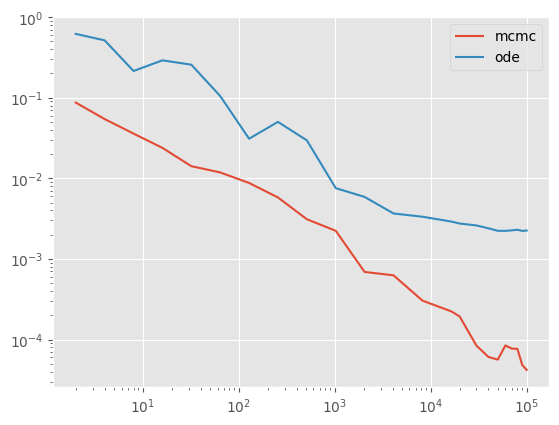

In [64]:
plt.plot(sample_nos, np.mean(wd_array / base_wd, axis=0), label="mcmc")
plt.plot(sample_nos, wd_ode, label="ode")
plt.xscale("log")
plt.yscale("log")
plt.legend()

In [12]:
mcmc_samps2[0][np.where(mcmc_samps2[0] < 0.85)[0]]

array([[-2.54093885],
       [-2.54093885],
       [-2.54093885],
       ...,
       [-2.54093885],
       [-2.54093885],
       [-2.54093885]], shape=(100000, 1))

In [23]:
np.sort(mcmc_samps2[1].squeeze())

array([-0.15122318, -0.15122318, -0.15122318, ...,  3.6256063 ,
        3.65382051,  3.69635677], shape=(100000,))